In [84]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [85]:
# Trade_DetailedTradeMatrix_E_All_Data.csv as Dataframe 

data = pd.read_csv('./data/UNComtrade/Trade_DetailedTradeMatrix_E_All_Data.csv')

print(data.columns)

print(data.shape)

print(data.head(5))

C:\Users\mbera\AppData\Local\Temp\ipykernel_20780\1907478174.py:3: DtypeWarning: Columns (0: Y1986F, 1: Y1987F, 2: Y1988F, 3: Y1989F, 4: Y1990F, 5: Y1991F, 6: Y1992F, 7: Y1993F, 8: Y1994F, 9: Y1995F, 10: Y1996F, 11: Y1997F, 12: Y1998F, 13: Y1999F, 14: Y2000F, 15: Y2001F, 16: Y2002F, 17: Y2003F, 18: Y2004F, 19: Y2005F, 20: Y2006F, 21: Y2007F, 22: Y2008F, 23: Y2009F, 24: Y2010F, 25: Y2011F, 26: Y2012F, 27: Y2013F, 28: Y2014F, 29: Y2015F, 30: Y2016F, 31: Y2017F, 32: Y2018F, 33: Y2019F, 34: Y2020F, 35: Y2021F, 36: Y2022F, 37: Y2023F, 38: Y2024F) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./data/UNComtrade/Trade_DetailedTradeMatrix_E_All_Data.csv')


Index(['Reporter Country Code', 'Reporter Country Code (M49)',
       'Reporter Countries', 'Partner Country Code',
       'Partner Country Code (M49)', 'Partner Countries', 'Item Code',
       'Item Code (CPC)', 'Item', 'Element Code', 'Element', 'Unit', 'Y1986',
       'Y1986F', 'Y1987', 'Y1987F', 'Y1988', 'Y1988F', 'Y1989', 'Y1989F',
       'Y1990', 'Y1990F', 'Y1991', 'Y1991F', 'Y1992', 'Y1992F', 'Y1993',
       'Y1993F', 'Y1994', 'Y1994F', 'Y1995', 'Y1995F', 'Y1996', 'Y1996F',
       'Y1997', 'Y1997F', 'Y1998', 'Y1998F', 'Y1999', 'Y1999F', 'Y2000',
       'Y2000F', 'Y2001', 'Y2001F', 'Y2002', 'Y2002F', 'Y2003', 'Y2003F',
       'Y2004', 'Y2004F', 'Y2005', 'Y2005F', 'Y2006', 'Y2006F', 'Y2007',
       'Y2007F', 'Y2008', 'Y2008F', 'Y2009', 'Y2009F', 'Y2010', 'Y2010F',
       'Y2011', 'Y2011F', 'Y2012', 'Y2012F', 'Y2013', 'Y2013F', 'Y2014',
       'Y2014F', 'Y2015', 'Y2015F', 'Y2016', 'Y2016F', 'Y2017', 'Y2017F',
       'Y2018', 'Y2018F', 'Y2019', 'Y2019F', 'Y2020', 'Y2020F', 'Y2021',


Dataset contains data for several types of trades, not only coffee. Let's isolate what interests us.

In [86]:
data_clean = data.drop(['Reporter Country Code', 'Reporter Country Code (M49)', 'Partner Country Code',
       'Partner Country Code (M49)'], axis=1)

data_clean = data_clean.drop(data_clean[~data_clean['Item'].str.contains('coffee', case=False)].index)

print(data_clean.shape)
data_clean.head(5)

print("Items: ", data_clean['Item'].unique(), "\n")
print("Elements: ", data_clean['Element'].unique(), "\n")
print("Units: ", data_clean['Unit'].unique(), "\n")
print("Y2020: ", data_clean['Y2020'].unique(), "\n")
print("Y2020F: ", data_clean['Y2020F'].unique(), "\n")

# drop rows with something else than "Coffee, green" or "Coffee, decaffeinated or roasted"
data_clean = data_clean.drop(data_clean[~data_clean['Item'].str.contains('Coffee, green|Coffee, decaffeinated or roasted', case=False)].index)

data_brasil = data_clean[data_clean['Reporter Countries'] == 'Brazil']
data_germany = data_clean[data_clean['Reporter Countries'] == 'Germany']

print(data_brasil.head(8))

print(data_germany.head(8))

# Item Code
RAW_COFFEE_CODE = 656
TRANSFORMED_COFFEE_CODE = 657

# Element Code
EXPORT_QUANTITY_CODE = 5910
EXPORT_VALUE_CODE = 5922
IMPORT_QUANTITY_CODE = 5610
IMPORT_VALUE_CODE = 5622

data_clean = data_clean.drop(['Item Code (CPC)', 'Item', 'Element'], axis=1)

print(data_clean.head(5))

# drop the row if no data, e.g. columns from since "Y1986" are all NaN
data_clean = data_clean.dropna(subset=data_clean.columns[5:], how='all')
print(data_clean.shape)

# drop the columns if it contains only NaN
data_clean = data_clean.dropna(axis=1, how='all')
print(data_clean.shape)

# drops the rows where 'Element Code' is not in [EXPORT_VALUE_CODE, IMPORT_VALUE_CODE]
data_value = data_clean.drop(data_clean[~data_clean['Element Code'].isin([EXPORT_VALUE_CODE, IMPORT_VALUE_CODE])].index).reset_index(drop=True)
print(data_value.shape)

# drops the rows where 'Element Code' is not in [EXPORT_QUANTITY_CODE, IMPORT_QUANTITY_CODE]
data_quantity = data_clean.drop(data_clean[~data_clean['Element Code'].isin([EXPORT_QUANTITY_CODE, IMPORT_QUANTITY_CODE])].index).reset_index(drop=True)
print(data_quantity.shape)

data_quantity.head(10)

(136302, 86)
Items:  <StringArray>
[                   'Coffee, green',                  'Coffee extracts',
 'Coffee, decaffeinated or roasted',               'Coffee substitutes',
           'Coffee husks and skins']
Length: 5, dtype: str 

Elements:  <StringArray>
['Import quantity', 'Import value', 'Export quantity', 'Export value']
Length: 4, dtype: str 

Units:  <StringArray>
['t', '1000 USD']
Length: 2, dtype: str 

Y2020:  [    nan 2414.33 6129.   ...  121.94  162.59  175.98] 

Y2020F:  <StringArray>
[nan, 'A', 'I', 'X']
Length: 4, dtype: str 

       Reporter Countries Partner Countries  Item Code Item Code (CPC)  \
703182             Brazil       Afghanistan        657          '23911   
703183             Brazil       Afghanistan        657          '23911   
703367             Brazil           Albania        656          '01610   
703368             Brazil           Albania        656          '01610   
703551             Brazil           Algeria        657          '23911  

,Reporter Countries,Partner Countries,Item Code,Element Code,Unit,Y1986,Y1986F,Y1987,Y1987F,Y1988,...,Y2020,Y2020F,Y2021,Y2021F,Y2022,Y2022F,Y2023,Y2023F,Y2024,Y2024F
0,Afghanistan,Bulgaria,656,5610,t,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Eswatini,656,5610,t,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,India,656,5610,t,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Indonesia,656,5610,t,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Iran (Islamic Republic of),656,5610,t,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,Italy,656,5610,t,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,Malaysia,656,5610,t,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,Netherlands (Kingdom of the),656,5610,t,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,Türkiye,656,5610,t,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Afghanistan,Turkmenistan,656,5610,t,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now that we have two clean datasets, we can start exploring them.

End of fulfilliness check.


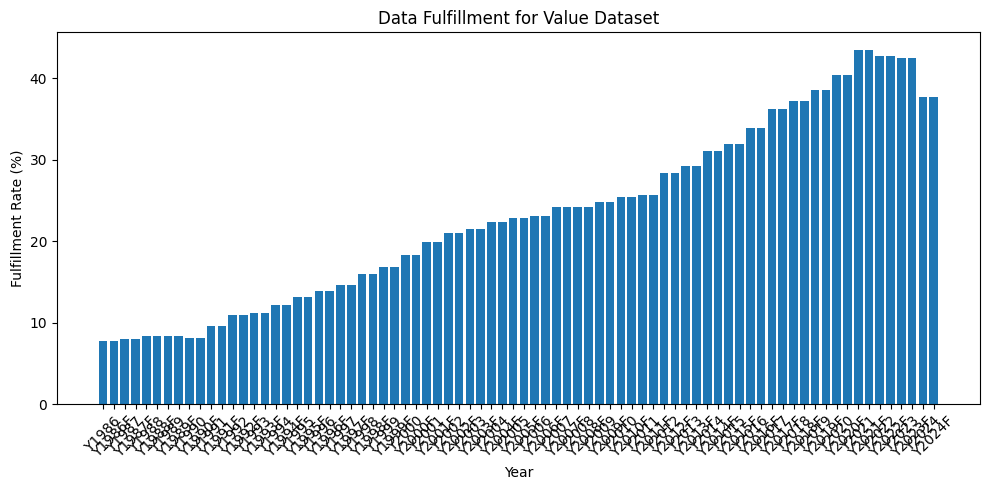

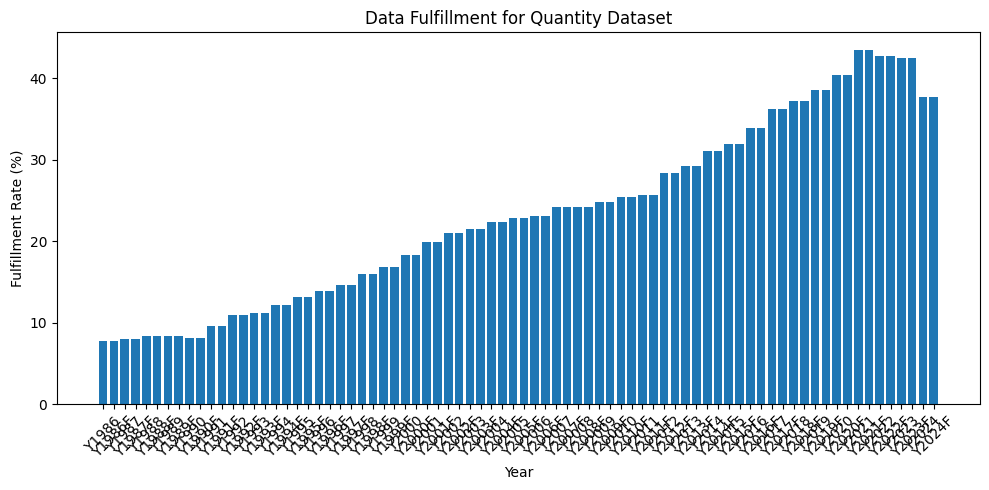

In [87]:
# Plot the data fulfilliness for the columns from Y1986 to Y2020F for the value dataset in percentage of non-NaN values

F_columns = data_value.columns[5:]
fulfilliness_value = []
fulfilliness_quantity = []
for col in F_columns:
    fulfilliness_value.append(data_value[col].notna().sum() / data_value.shape[0] * 100)
    fulfilliness_quantity.append(data_quantity[col].notna().sum() / data_quantity.shape[0] * 100)

    if (data_value[col].notna() != data_quantity[col].notna()).any():
        print(f"Column {col} has different fulfilliness between value and quantity datasets.")

print("End of fulfilliness check.")

plt.figure(figsize=(10, 5))
plt.bar(F_columns, fulfilliness_value)
plt.xlabel('Year')
plt.ylabel('Fulfillment Rate (%)')
plt.title('Data Fulfillment for Value Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(F_columns, fulfilliness_quantity)
plt.xlabel('Year')
plt.ylabel('Fulfillment Rate (%)')
plt.title('Data Fulfillment for Quantity Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



The Y....F columns tells where the data comes from, E for estimated, X for external organization, A official, I imputed by receiver. Let's see if A dominate the data, as we would expect.

End of source distribution check.


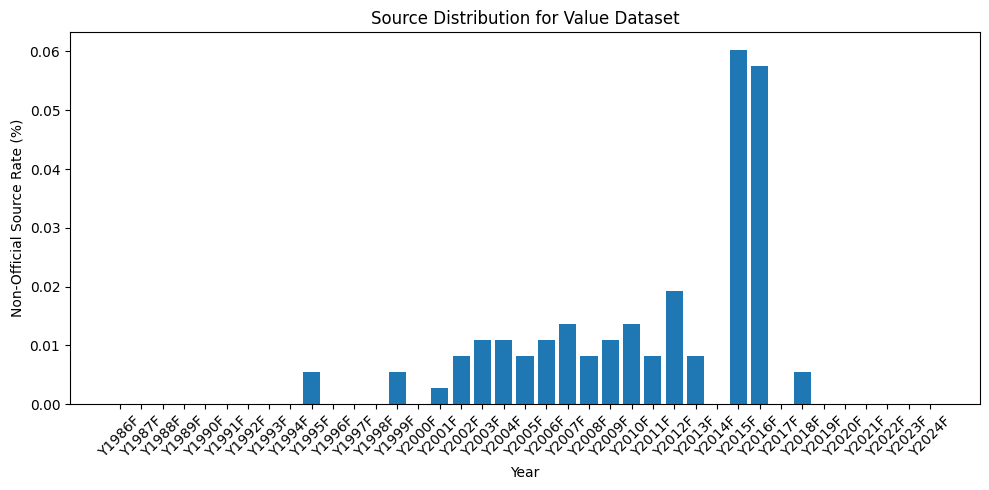

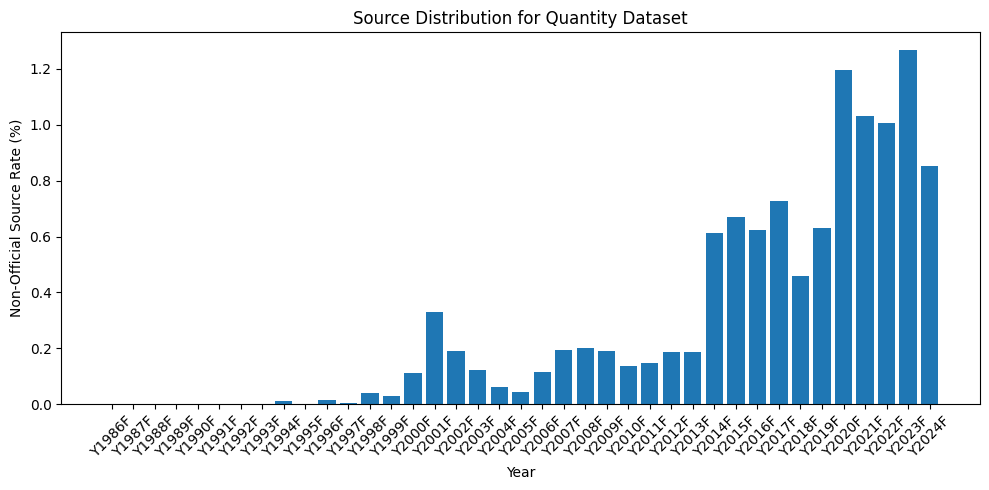

In [88]:
F_columns = data_value.columns[6::2]
source_value = []
source_quantity = []

for col in F_columns:
    source_value.append((data_value[col].dropna() != 'A').sum() / data_value.shape[0] * 100)
    source_quantity.append((data_quantity[col].dropna() != 'A').sum() / data_quantity.shape[0] * 100)

print("End of source distribution check.")

plt.figure(figsize=(10, 5))
plt.bar(F_columns, source_value)
plt.xlabel('Year')
plt.ylabel('Non-Official Source Rate (%)')
plt.title('Source Distribution for Value Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(F_columns, source_quantity)
plt.xlabel('Year')
plt.ylabel('Non-Official Source Rate (%)')
plt.title('Source Distribution for Quantity Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Since unofficial sources (E, X, I) represents at most 1.3% of the data, we can consider that the data is mostly official, and hence drop the source information for the rest of the analysis.

In [89]:
data_value_light = data_value.drop(data_value.columns[6::2], axis=1).reset_index(drop=True)
data_quantity_light = data_quantity.drop(data_quantity.columns[6::2], axis=1).reset_index(drop=True)

print("Size with 0 values:")
print("Value shape:", data_value_light.shape)
print("Quantity shape:", data_quantity_light.shape)

for col in data_value_light.columns[5:] :
    unique_vals = data_value_light[col].unique()
    unique_vals.sort()
    print(f"{col}: ", unique_vals, "\n")

# Removing zero values
data_value_light = data_value_light.replace(0, np.nan).dropna(subset=data_value_light.columns[5:], how='all')
data_quantity_light = data_quantity_light.replace(0, np.nan).dropna(subset=data_quantity_light.columns[5:], how='all')

print("Size after dropping 0 values:")
print("Value shape:", data_value_light.shape)
print("Quantity shape:", data_quantity_light.shape)

# keep only the rows that are both in data_value_light and data_quantity_light, based on row numbers
data_value_light = data_value_light[data_value_light.index.isin(data_quantity_light.index)]
data_quantity_light = data_quantity_light[data_quantity_light.index.isin(data_value_light.index)]

print("Size after keeping only the rows that are both in value and quantity datasets:")
print("Value shape:", data_value_light.shape)
print("Quantity shape:", data_quantity_light.shape)

data_value_light.reset_index(drop=True)
data_quantity_light.reset_index(drop=True)

print(data_value_light.head(10))


# save to csv
data_value_light.to_csv('./data/UNComtrade/Trade_Matrix_Value.csv', index=False)
data_quantity_light.to_csv('./data/UNComtrade/Trade_Matrix_Quantity.csv', index=False)

Size with 0 values:
Value shape: (36521, 44)
Quantity shape: (36521, 44)
Y1986:  [0.00000e+00 1.00000e+00 2.00000e+00 ... 5.85708e+05 6.80463e+05
         nan] 

Y1987:  [0.00000e+00 1.00000e+00 2.00000e+00 ... 4.66714e+05 5.28454e+05
         nan] 

Y1988:  [0.00000e+00 1.00000e+00 2.00000e+00 ... 5.07118e+05 6.13405e+05
         nan] 

Y1989:  [0.00000e+00 1.00000e+00 2.00000e+00 ... 4.81412e+05 5.03221e+05
         nan] 

Y1990:  [0.00000e+00 1.00000e+00 2.00000e+00 ... 3.32605e+05 3.42710e+05
         nan] 

Y1991:  [0.00000e+00 1.00000e+00 2.00000e+00 ... 4.45770e+05 5.20909e+05
         nan] 

Y1992:  [0.00000e+00 1.00000e+00 2.00000e+00 ... 4.40351e+05 5.03761e+05
         nan] 

Y1993:  [0.00000e+00 1.00000e+00 2.00000e+00 ... 4.41875e+05 4.68222e+05
         nan] 

Y1994:  [0.00000e+00 1.00000e+00 2.00000e+00 ... 5.69629e+05 7.13886e+05
         nan] 

Y1995:  [0.00000e+00 1.00000e+00 2.00000e+00 ... 6.08276e+05 7.78573e+05
         nan] 

Y1996:  [0.00000e+00 1.00000e+00 2.00

Now that the data is clean, we can start exploring it. Let's plot an example of the data, e.g. the quantity of export and import for the Germany.

In [90]:
def plot_quantity_trends(data_quantity, country_name=""):
    years = data_quantity.columns[5:]
    exports = []
    imports = []

    for col in years:
        export_sum = data_quantity[data_quantity['Element Code'] == EXPORT_QUANTITY_CODE][col].sum()
        import_sum = data_quantity[data_quantity['Element Code'] == IMPORT_QUANTITY_CODE][col].sum()
        exports.append(export_sum)
        imports.append(import_sum)

    x = np.arange(len(years))
    width = 0.35

    fig, ax = plt.subplots(figsize=(15, 6))
    rects1 = ax.bar(x - width/2, exports, width, label='Export', color='blue')
    rects2 = ax.bar(x + width/2, imports, width, label='Import', color='orange')

    ax.set_ylabel('Quantity')
    # if country_name not ""
    if country_name:
        ax.set_title(f'Quantity of Export and Import for {country_name} by Year')
    else:
        ax.set_title('Quantity of Export and Import by Year')
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    ax.legend()

    plt.tight_layout()
    plt.show()

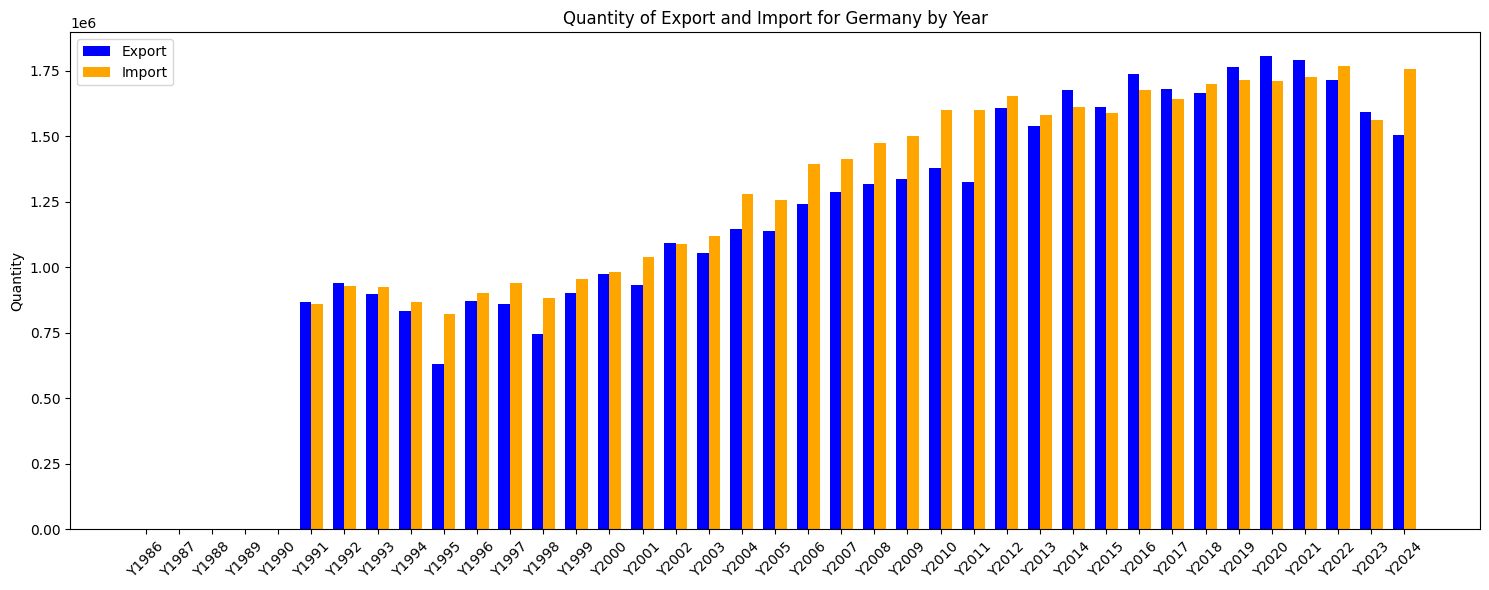

In [91]:
data_germany = pd.read_csv('./data/UNComtrade/Trade_Matrix_Quantity.csv')
data_germany = data_germany[(data_germany['Reporter Countries'] == 'Germany') | (data_germany['Partner Countries'] == 'Germany')].reset_index(drop=True)

plot_quantity_trends(data_germany, country_name="Germany")


Interesting, we can even go deeper in details, differentiating the raw and transformed coffee.

In [92]:

def plot_detailed_quantity_trends(data_quantity, country_name=""):
    years = data_quantity.columns[5:]

    exports_raw = []
    exports_transformed = []
    imports_raw = []
    imports_transformed = []

    for col in years:
        ex_r = data_quantity[(data_quantity['Element Code'] == EXPORT_QUANTITY_CODE) & (data_quantity['Item Code'] == RAW_COFFEE_CODE)][col].sum()
        ex_t = data_quantity[(data_quantity['Element Code'] == EXPORT_QUANTITY_CODE) & (data_quantity['Item Code'] == TRANSFORMED_COFFEE_CODE)][col].sum()
        
        im_r = data_quantity[(data_quantity['Element Code'] == IMPORT_QUANTITY_CODE) & (data_quantity['Item Code'] == RAW_COFFEE_CODE)][col].sum()
        im_t = data_quantity[(data_quantity['Element Code'] == IMPORT_QUANTITY_CODE) & (data_quantity['Item Code'] == TRANSFORMED_COFFEE_CODE)][col].sum()
        
        exports_raw.append(ex_r)
        exports_transformed.append(ex_t)
        imports_raw.append(im_r)
        imports_transformed.append(im_t)

    x = np.arange(len(years))
    width = 0.2

    fig, ax = plt.subplots(figsize=(18, 7))

    ax.bar(x - 1.5*width, imports_raw, width, label='Import Raw', color='#1f77b4')
    ax.bar(x - 0.5*width, imports_transformed, width, label='Import Transformed', color='#aec7e8')
    ax.bar(x + 0.5*width, exports_raw, width, label='Export Raw', color='#ff7f0e')
    ax.bar(x + 1.5*width, exports_transformed, width, label='Export Transformed', color='#ffbb78')

    ax.set_ylabel('Quantity')
    if country_name:
        ax.set_title(f'Quantity of Coffee Trade for {country_name} (Raw vs Transformed)')
    else:
        ax.set_title('Quantity of Coffee Trade (Raw vs Transformed)')
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    ax.legend()

    plt.tight_layout()
    plt.show()

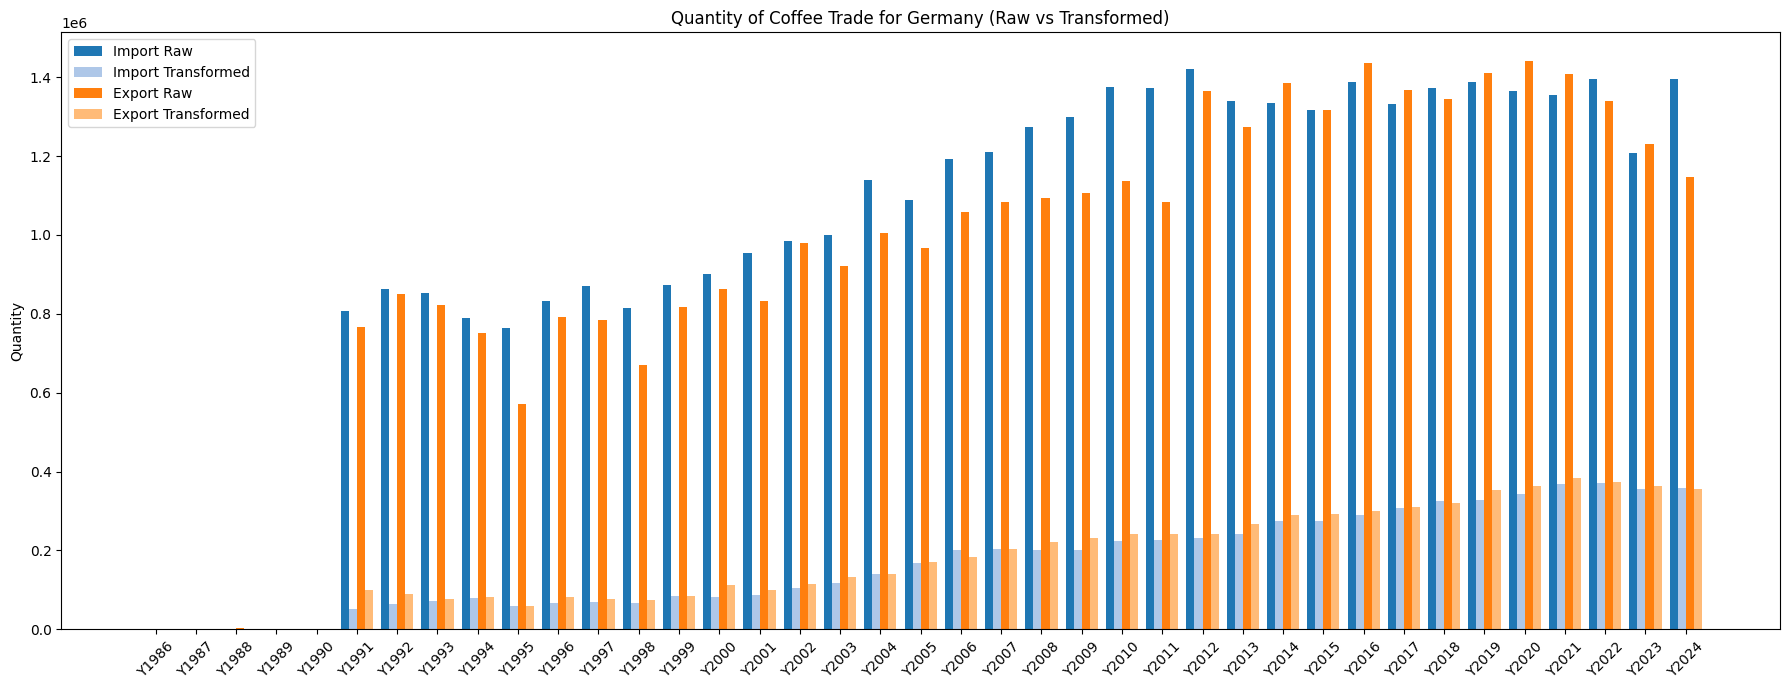

In [93]:
data_germany = pd.read_csv('./data/UNComtrade/Trade_Matrix_Quantity.csv')
data_germany = data_germany[(data_germany['Reporter Countries'] == 'Germany') | (data_germany['Partner Countries'] == 'Germany')].reset_index(drop=True)

plot_detailed_quantity_trends(data_germany, country_name="Germany")

Let's see for Brazil, a known major coffee producer.

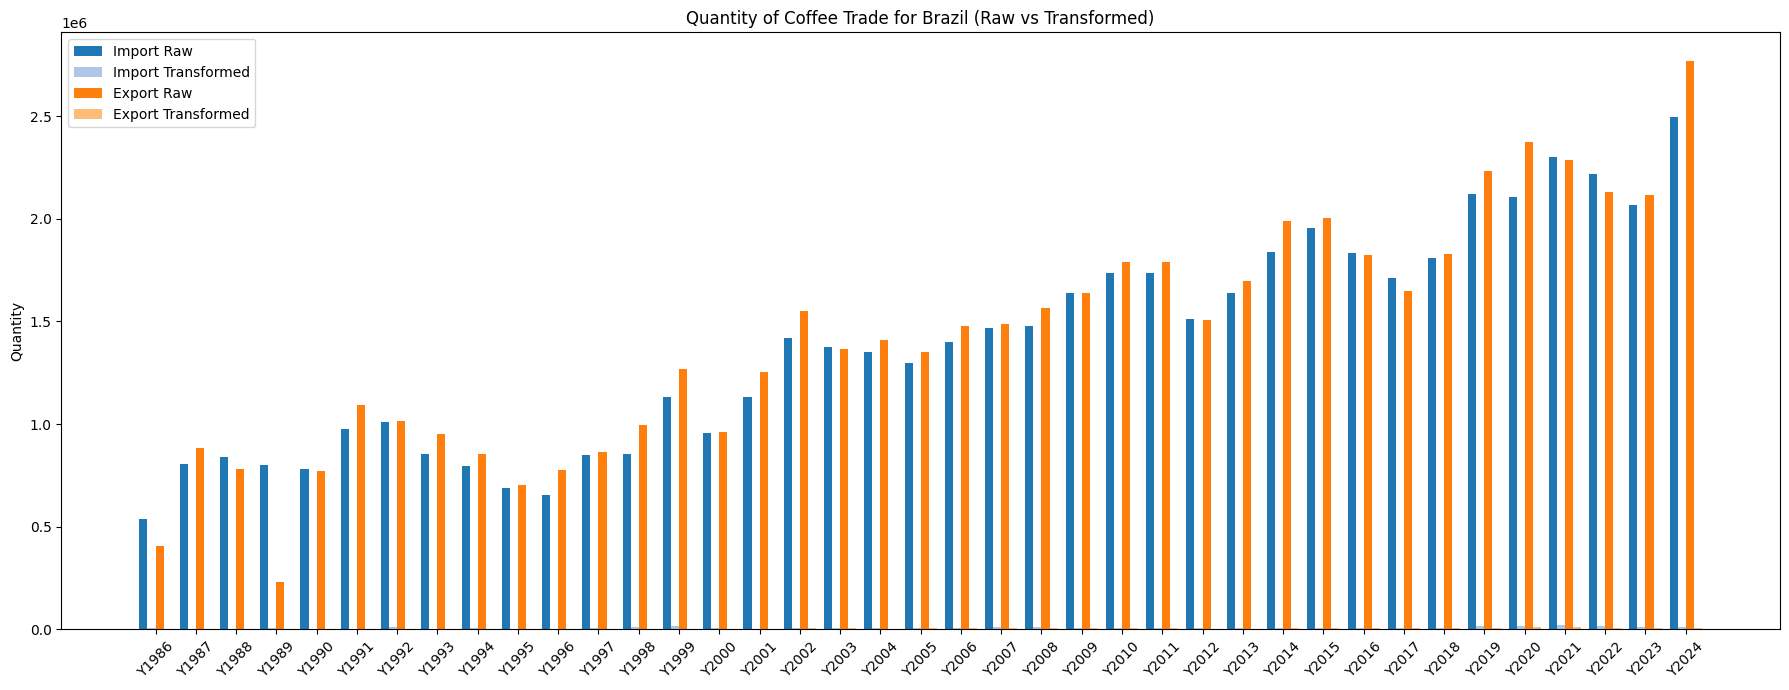

In [94]:
data_brazil = pd.read_csv('./data/UNComtrade/Trade_Matrix_Quantity.csv')
data_brazil = data_brazil[(data_brazil['Reporter Countries'] == 'Brazil') | (data_brazil['Partner Countries'] == 'Brazil')].reset_index(drop=True)

plot_detailed_quantity_trends(data_brazil, country_name="Brazil")

And what about Switzerland?

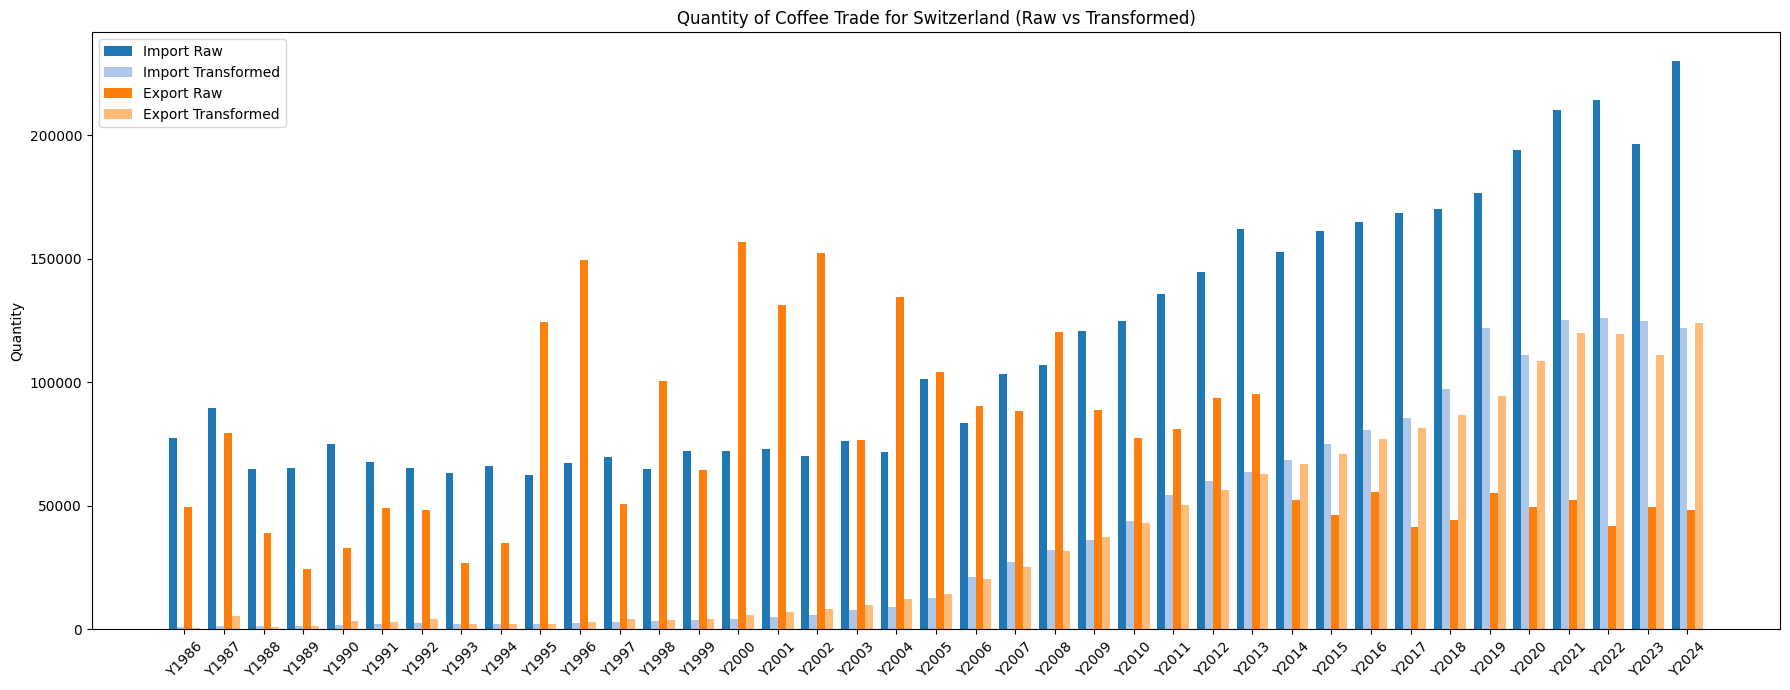

In [95]:
data_switzerland = pd.read_csv('./data/UNComtrade/Trade_Matrix_Quantity.csv')
data_switzerland = data_switzerland[(data_switzerland['Reporter Countries'] == 'Switzerland') | (data_switzerland['Partner Countries'] == 'Switzerland')].reset_index(drop=True)

plot_detailed_quantity_trends(data_switzerland, country_name="Switzerland")